<a href="https://colab.research.google.com/github/shamiadnan/Boston-House-Prices-Predicton/blob/main/BostonHousePricePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
#Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
import xgboost as xgb
from sklearn.preprocessing import StandardScaler

In [36]:
# Load Dataset

df = pd.read_csv('/content/drive/MyDrive/Boston_House_Price_prediction/HousingData.csv')


In [37]:
print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (506, 14)
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90    NaN  36.2  


In [38]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,486.000000,486.000000,486.000000,486.000000,506.000000,506.000000,486.000000,506.000000,506.000000,506.000000,506.000000,506.000000,486.000000,506.000000
mean,3.611874,11.211934,11.083992,0.069959,0.554695,6.284634,68.518519,3.795043,9.549407,408.237154,18.455534,356.674032,12.715432,22.532806
std,8.720192,23.388876,6.835896,0.255340,0.115878,0.702617,27.999513,2.105710,8.707259,168.537116,2.164946,91.294864,7.155871,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.081900,0.000000,5.190000,0.000000,0.449000,5.885500,45.175000,2.100175,4.000000,279.000000,17.400000,375.377500,7.125000,17.025000
50%,0.253715,0.000000,9.690000,0.000000,0.538000,6.208500,76.800000,3.207450,5.000000,330.000000,19.050000,391.440000,11.430000,21.200000
75%,3.560263,12.500000,18.100000,0.000000,0.624000,6.623500,93.975000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [40]:
print(df.isnull().sum())

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64


In [41]:
# Data Cleaning

# Replace 'NA' with actual NaN
df.replace("NA", np.nan, inplace=True)

# Convert all columns to numeric
df = df.apply(pd.to_numeric, errors="coerce")

# Fill missing values with column median
df = df.fillna(df.median())

print(df.isnull().sum())  # check again


CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


In [43]:
# Exploratory Data Analysis (EDA)
# Statistical Info
print(df.describe())

             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean     3.479140   10.768775   11.028893    0.067194    0.554695    6.284634   
std      8.570832   23.025124    6.704679    0.250605    0.115878    0.702617   
min      0.006320    0.000000    0.460000    0.000000    0.385000    3.561000   
25%      0.083235    0.000000    5.190000    0.000000    0.449000    5.885500   
50%      0.253715    0.000000    9.690000    0.000000    0.538000    6.208500   
75%      2.808720    0.000000   18.100000    0.000000    0.624000    6.623500   
max     88.976200  100.000000   27.740000    1.000000    0.871000    8.780000   

              AGE         DIS         RAD         TAX     PTRATIO           B  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   
mean    68.845850    3.795043    9.549407  408.237154   18.455534  356.674032   
std     27.486962    2.1057

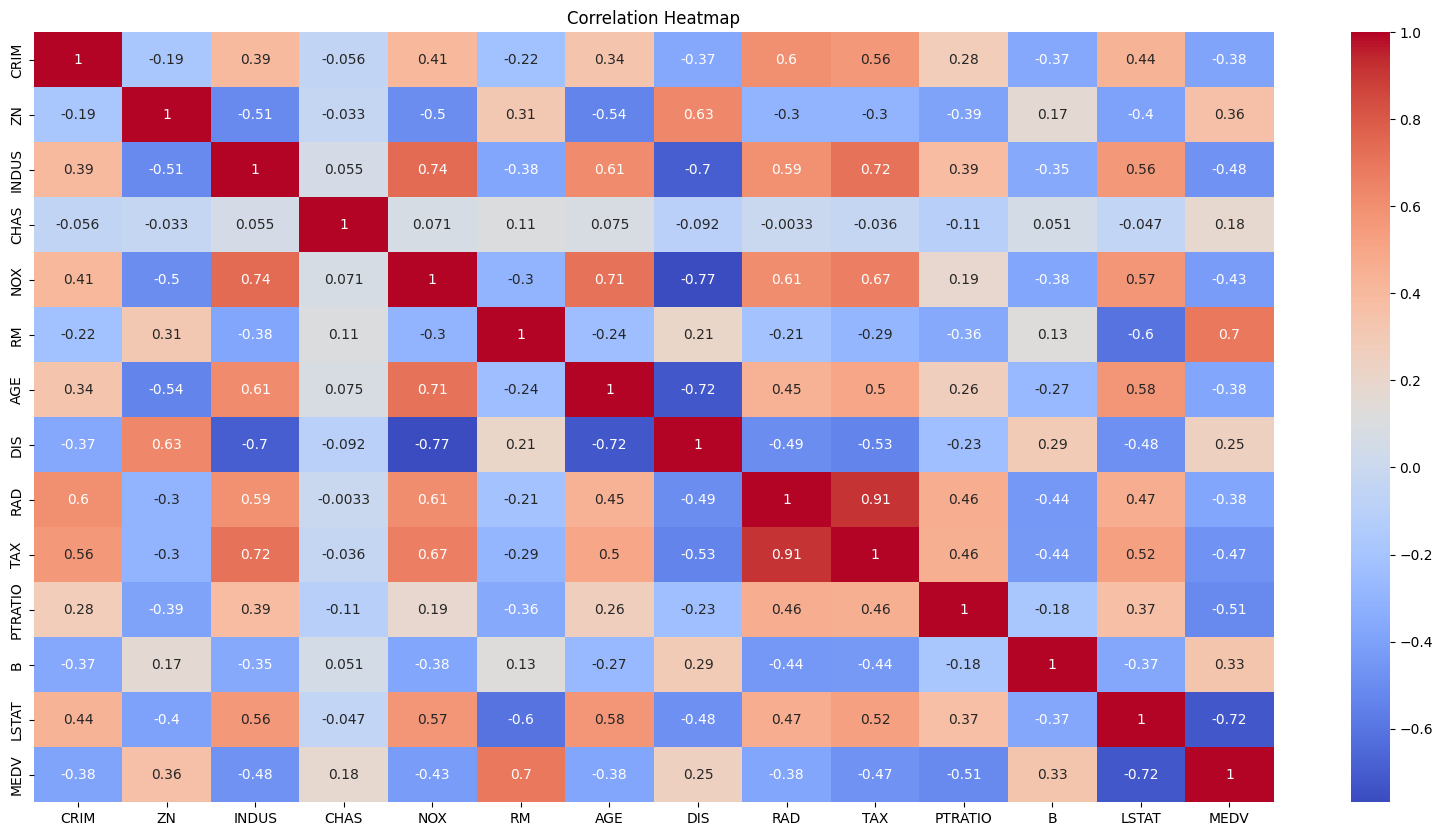

In [44]:
# Correlation heatmap
plt.figure(figsize=(20,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

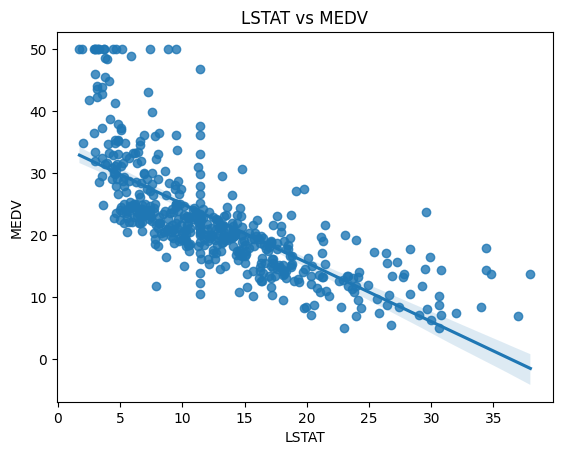

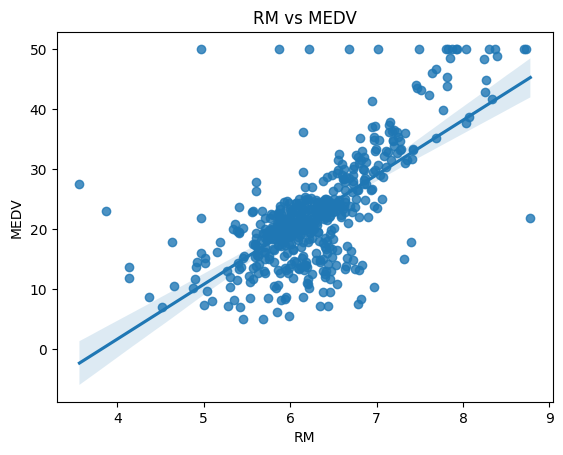

In [58]:
# Key relationships

sns.regplot(x=df['LSTAT'], y=df['MEDV'])
plt.title("LSTAT vs MEDV")
plt.show()

sns.regplot(x=df['RM'], y=df['MEDV'])
plt.title("RM vs MEDV")
plt.show()

In [48]:
# Feature Scaling (Standardization only, consistent choice)

cols_to_scale = ['CRIM','ZN','TAX','B']
scaler = StandardScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

In [49]:
# Split Features & Target

X = df.drop(columns=['MEDV','RAD'], axis=1)
y = df['MEDV']

In [50]:
# Model Training Function

def train(model, X, y):
    x_train, x_test, y_train, y_test = train_test_split(X, y, random_state=42)
    model.fit(x_train, y_train)
    pred = model.predict(x_test)
    cv_score = cross_val_score(model, X, y, scoring='neg_mean_squared_error', cv=5)
    cv_score = np.abs(np.mean(cv_score))
    return mean_squared_error(y_test, pred), r2_score(y_test, pred), cv_score, pred, y_test

In [53]:
# Train Models & Collect Results

results = {}

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Extra Trees": ExtraTreesRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": xgb.XGBRegressor(random_state=42)
}

for name, model in models.items():
    mse, r2, cv, pred, y_test = train(model, X, y)
    results[name] = [mse, r2, cv]
    print(f"{name} -> MSE: {mse:.2f}, R²: {r2:.2f}, CV Score: {cv:.2f}")

Linear Regression -> MSE: 23.84, R²: 0.66, CV Score: 35.86
Decision Tree -> MSE: 24.81, R²: 0.65, CV Score: 43.07
Random Forest -> MSE: 9.89, R²: 0.86, CV Score: 22.20
Extra Trees -> MSE: 12.25, R²: 0.83, CV Score: 19.53
Gradient Boosting -> MSE: 8.32, R²: 0.88, CV Score: 19.75
XGBoost -> MSE: 8.87, R²: 0.87, CV Score: 25.38


In [54]:
# Compare Models in a Table

results_df = pd.DataFrame(results, index=['MSE','R²','CV Score']).T
print("\nModel Comparison:\n", results_df)


Model Comparison:
                          MSE        R²   CV Score
Linear Regression  23.839110  0.659573  35.859119
Decision Tree      24.809606  0.645714  43.068963
Random Forest       9.894719  0.858702  22.200042
Extra Trees        12.250112  0.825066  19.531630
Gradient Boosting   8.320351  0.881184  19.745429
XGBoost             8.872019  0.873306  25.379501


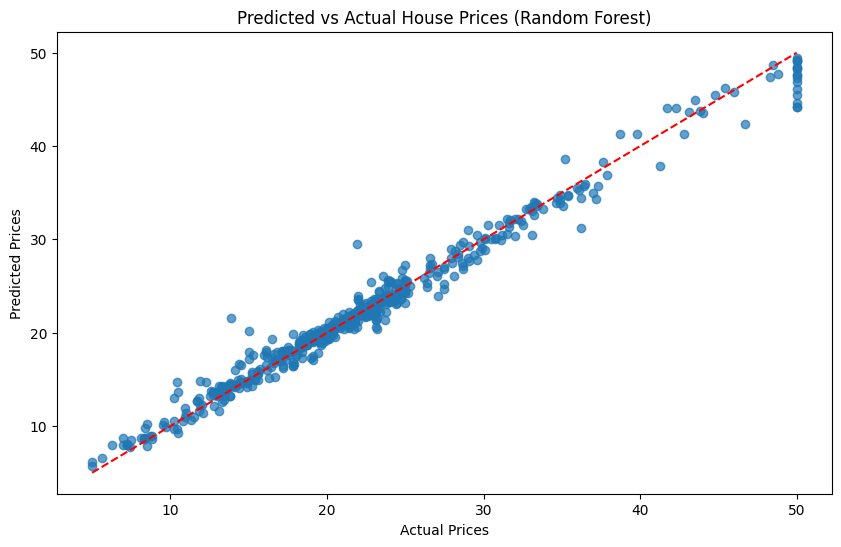

In [61]:
# Visualize Predicted vs Actual (Best Model Example: Random Forest)

rf = RandomForestRegressor(random_state=42)
rf.fit(X, y)
y_pred_rf = rf.predict(X)

plt.figure(figsize=(10,6))
plt.scatter(y, y_pred_rf, alpha=0.7)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Predicted vs Actual House Prices (Random Forest)")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.show()

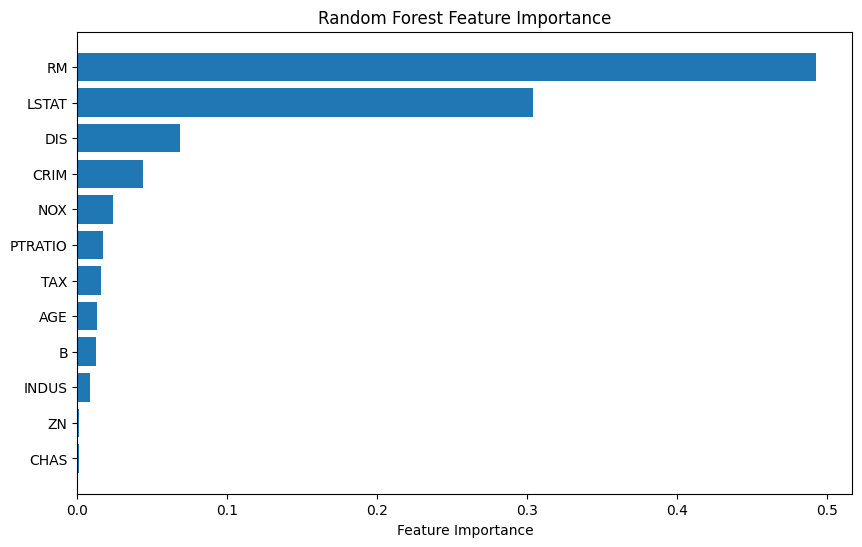

In [57]:
# Feature Importance (Random Forest)
importances = rf.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10,6))
plt.barh(range(len(indices)), importances[indices], align="center")
plt.yticks(range(len(indices)), X.columns[indices])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.show()